In [1]:
import os
from utils.eda_utils import EDAUtils, FeatureEngineering, DataCleaningUtils
from utils.ml_utils_v2 import RegressionAnalysis, FeaturePredictiveEvaluator
import joblib
import pandas as pd
from scipy.stats import skew
import numpy as np
import matplotlib.pyplot as plt


In [2]:
%load_ext autoreload
%autoreload 2

In [3]:
eda_utils = EDAUtils()
dcu = DataCleaningUtils()
fe = FeatureEngineering()

In [4]:
SCRIPT_DIR_PATH = os.getcwd()
ROOT_DIR_PATH = os.path.dirname(SCRIPT_DIR_PATH)
DATA_DIR_PATH = os.path.join(ROOT_DIR_PATH, "data")
PROCESSED_DATA_DIR_PATH = os.path.join(DATA_DIR_PATH, "processed_data")
RESULTS_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "results")
OUTPUT_DIR_PATH = os.path.join(SCRIPT_DIR_PATH, "output")
ENSEMBLE_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "ensemble")
MODELS_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "models")
TRAINING_DIR_PATH = os.path.join(OUTPUT_DIR_PATH, "training")

# Make sure the output directories exist
os.makedirs(ENSEMBLE_DIR_PATH, exist_ok=True)
os.makedirs(MODELS_DIR_PATH, exist_ok=True)
os.makedirs(TRAINING_DIR_PATH, exist_ok=True)

## 1. Load Historical Emissions Data, World Bank Indicators Data, and Policy Data

In [5]:
# Load the emissions data
emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "historical_total_emission_per_country.csv"))
# emissions_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "total_emissions_legacy.csv"))
emissions_df.head()

,iso_alpha_3,year,total_emissions
0,ABW,1970,0.036970
1,ABW,1971,0.041825
2,ABW,1972,0.052708
3,ABW,1973,0.057704
4,ABW,1974,0.056999


In [6]:
emissions_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12375 entries, 0 to 12374
Data columns (total 3 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   iso_alpha_3      12375 non-null  object 
 1   year             12375 non-null  int64  
 2   total_emissions  12375 non-null  float64
dtypes: float64(1), int64(1), object(1)
memory usage: 290.2+ KB


In [7]:
# Check emissions max year
emissions_df['year'].max()

np.int64(2024)

In [8]:
# Load the wb indicators
wb_df = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "wb_indicators_filtered.csv"))
wb_df.head()

,iso_alpha_3,year,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,gdp_per_capita_growth_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,ALB,1980,2.047964,41.13,2671997.0,23.957492,NaN,NaN,NaN,NaN,...,NaN,160.170940,48.98,40.802920,21.350365,NaN,NaN,NaN,NaN,NaN
1,ALB,1981,2.002974,42.77,2726056.0,23.810507,NaN,NaN,NaN,3.648649,...,NaN,138.435374,50.89,40.729927,21.459854,NaN,NaN,NaN,5.745635,NaN
2,ALB,1982,2.113272,44.14,2784278.0,20.072918,NaN,NaN,NaN,0.795840,...,NaN,179.966044,53.23,40.656934,21.496350,NaN,NaN,NaN,2.948597,NaN
3,ALB,1983,2.120885,48.08,2843960.0,18.852075,NaN,NaN,NaN,-1.016802,...,NaN,174.363328,59.51,40.510949,21.496350,NaN,NaN,NaN,1.104938,NaN
4,ALB,1984,2.103937,44.62,2904429.0,18.040331,NaN,NaN,NaN,-3.307497,...,NaN,159.592530,54.66,40.620438,21.496350,NaN,NaN,NaN,-1.251597,NaN


In [9]:
wb_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7695 entries, 0 to 7694
Data columns (total 25 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   pop_growth                                      7693 non-null   float64
 3   food_production_index                           7014 non-null   float64
 4   pop_total                                       7695 non-null   float64
 5   exports_pct_of_gdp                              6461 non-null   float64
 6   renewable_energy_output_pct                     4962 non-null   float64
 7   energy_use_kg_of_oil_equivalent_per_capita      4823 non-null   float64
 8   population_in_urban_agglomerations_over_1m_pct  5265 non-null   float64
 9   gdp_per_capita_growth_pct                

In [10]:
# check wb data max year
wb_df['year'].max()

np.int64(2024)

In [11]:
# load the policy index data
policy_indices = pd.read_csv(os.path.join(PROCESSED_DATA_DIR_PATH, "IEA_policy_count_x_gov.csv"))
policy_indices.head()

,iso_alpha_3,year,policy_flow_jur_stock_x_gov
0,AFG,1996,-14.082905
1,AFG,1998,-16.024521
2,AFG,2000,-16.717959
3,AFG,2002,-10.355287
4,AFG,2003,-9.881109


In [12]:
policy_indices["year"].max()

np.int64(2024)

## 2. Merge All Data

In [13]:
print("policy indices shape:", policy_indices.shape)
print("indicators shape:", wb_df.shape)
policies_and_indicators_df = pd.merge(policy_indices, wb_df, on=["iso_alpha_3", "year"], how="right")
print("merged shape:", policies_and_indicators_df.shape)
policies_and_indicators_df.head()

policy indices shape: (4834, 3)
indicators shape: (7695, 25)
merged shape: (7695, 26)


,iso_alpha_3,year,policy_flow_jur_stock_x_gov,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,...,gdp_per_capita_2021_ppp_intl_usd,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp
0,ALB,1980,NaN,2.047964,41.13,2671997.0,23.957492,NaN,NaN,NaN,...,NaN,160.170940,48.98,40.802920,21.350365,NaN,NaN,NaN,NaN,NaN
1,ALB,1981,NaN,2.002974,42.77,2726056.0,23.810507,NaN,NaN,NaN,...,NaN,138.435374,50.89,40.729927,21.459854,NaN,NaN,NaN,5.745635,NaN
2,ALB,1982,NaN,2.113272,44.14,2784278.0,20.072918,NaN,NaN,NaN,...,NaN,179.966044,53.23,40.656934,21.496350,NaN,NaN,NaN,2.948597,NaN
3,ALB,1983,NaN,2.120885,48.08,2843960.0,18.852075,NaN,NaN,NaN,...,NaN,174.363328,59.51,40.510949,21.496350,NaN,NaN,NaN,1.104938,NaN
4,ALB,1984,NaN,2.103937,44.62,2904429.0,18.040331,NaN,NaN,NaN,...,NaN,159.592530,54.66,40.620438,21.496350,NaN,NaN,NaN,-1.251597,NaN


In [14]:
# merge with emissions data
print("policies and indicators shape:", policies_and_indicators_df.shape)
print("emissions shape:", emissions_df.shape)
merged_df = pd.merge(policies_and_indicators_df, emissions_df, on=['iso_alpha_3', 'year'], how='inner')
print("final merged shape:", merged_df.shape)
merged_df.head()

policies and indicators shape: (7695, 26)
emissions shape: (12375, 3)
final merged shape: (7695, 27)


,iso_alpha_3,year,policy_flow_jur_stock_x_gov,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
0,ALB,1980,NaN,2.047964,41.13,2671997.0,23.957492,NaN,NaN,NaN,...,160.170940,48.98,40.802920,21.350365,NaN,NaN,NaN,NaN,NaN,12.578300
1,ALB,1981,NaN,2.002974,42.77,2726056.0,23.810507,NaN,NaN,NaN,...,138.435374,50.89,40.729927,21.459854,NaN,NaN,NaN,5.745635,NaN,11.619556
2,ALB,1982,NaN,2.113272,44.14,2784278.0,20.072918,NaN,NaN,NaN,...,179.966044,53.23,40.656934,21.496350,NaN,NaN,NaN,2.948597,NaN,12.264404
3,ALB,1983,NaN,2.120885,48.08,2843960.0,18.852075,NaN,NaN,NaN,...,174.363328,59.51,40.510949,21.496350,NaN,NaN,NaN,1.104938,NaN,13.114931
4,ALB,1984,NaN,2.103937,44.62,2904429.0,18.040331,NaN,NaN,NaN,...,159.592530,54.66,40.620438,21.496350,NaN,NaN,NaN,-1.251597,NaN,13.428858


In [15]:
merged_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7695 entries, 0 to 7694
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   policy_flow_jur_stock_x_gov                     4319 non-null   float64
 3   pop_growth                                      7693 non-null   float64
 4   food_production_index                           7014 non-null   float64
 5   pop_total                                       7695 non-null   float64
 6   exports_pct_of_gdp                              6461 non-null   float64
 7   renewable_energy_output_pct                     4962 non-null   float64
 8   energy_use_kg_of_oil_equivalent_per_capita      4823 non-null   float64
 9   population_in_urban_agglomerations_over_1

## 3. Data Cleaning

### Data Imputation

In [16]:
(
    merged_df
    .query("iso_alpha_3 == 'USA'")
    [["year", "fossil_fuel_energy_consumption_pct"]]
    .tail(15)
)


,year,fossil_fuel_energy_consumption_pct
7320,2010,84.123387
7321,2011,83.887674
7322,2012,83.944603
7323,2013,82.972888
7324,2014,83.401990
7325,2015,82.325816
7326,2016,0.000000
7327,2017,0.000000
7328,2018,0.000000
7329,2019,0.000000


In [17]:
merged_df[(merged_df["year"].isin([2022, 2023, 2024])) & (merged_df.iso_alpha_3 == "USA")].sort_values(by=["iso_alpha_3", "year"]).head(20)

,iso_alpha_3,year,policy_flow_jur_stock_x_gov,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
7332,USA,2022,5888.622631,0.575745,100.86,334017321.0,11.784405,NaN,6511.688414,46.858159,...,127.804791,92.96,46.082979,16.567975,NaN,NaN,33.866926,2.512375,NaN,6074.236155
7333,USA,2023,6030.532851,0.831493,NaN,336806231.0,11.184413,NaN,6363.500158,46.882614,...,127.796948,NaN,46.082979,16.568992,NaN,NaN,33.866926,2.887556,NaN,5890.986428
7334,USA,2024,6698.267370,0.976422,NaN,340110988.0,11.107457,NaN,NaN,46.846426,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.793001,NaN,5912.617724


In [18]:
merged_df[merged_df['iso_alpha_3'] == 'USA'].iloc[-1]

iso_alpha_3                                                         USA
year                                                               2024
policy_flow_jur_stock_x_gov                                  6698.26737
pop_growth                                                     0.976422
food_production_index                                               NaN
pop_total                                                   340110988.0
exports_pct_of_gdp                                            11.107457
renewable_energy_output_pct                                         NaN
energy_use_kg_of_oil_equivalent_per_capita                          NaN
population_in_urban_agglomerations_over_1m_pct                46.846426
gdp_per_capita_growth_pct                                      1.794192
industry_pct_of_gdp                                                 NaN
fossil_fuel_energy_consumption_pct                                  NaN
cereal_yield_kg_per_hectare                                     

In [19]:
# variables where zero is *never* a real value
pct_vars = [
    "forest_area_pct",
    "agricultural_land_pct",
    "arable_land_pct",
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
]

# variables where zero *could* be valid
level_vars = [
    "cereal_yield_kg_per_hectare",
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
    "policy_flow_jur_stock_x_gov"
]

share_vars = [
    "exports_pct_of_gdp",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
]


In [20]:
merged_df_cleaned = merged_df.sort_values(["iso_alpha_3", "year"]).copy()

merged_df_cleaned[pct_vars] = (
    merged_df_cleaned[pct_vars]
        .mask(merged_df_cleaned[pct_vars] <= 0)
)


In [21]:
def interpolate_slow(x):
    return (
        x.interpolate(
            method="linear",
            limit_direction="both",
            limit=10   # slow-moving structural vars
        )
    )

def interpolate_scale(x):
    return (
        x.interpolate(
            method="linear",
            limit_direction="both",
            limit=10
        )
    )

def interpolate_growth(x):
    return (
        x.interpolate(
            method="linear",
            limit=10
        )
    )


In [22]:
slow_vars = [
    "forest_area_pct",
    "agricultural_land_pct",
    "arable_land_pct",
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "cereal_yield_kg_per_hectare",
]

scale_vars = [
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
    "exports_pct_of_gdp",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
    "policy_flow_jur_stock_x_gov"
]

growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "food_production_index",
    "crop_production_index",
]

In [23]:
merged_df_cleaned[slow_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[slow_vars]
        .transform(interpolate_slow)
)

merged_df_cleaned[scale_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[scale_vars]
        .transform(interpolate_scale)
)

merged_df_cleaned[growth_vars] = (
    merged_df_cleaned
        .groupby("iso_alpha_3")[growth_vars]
        .transform(interpolate_growth)
)


In [24]:
merged_df_cleaned[pct_vars] = (
    merged_df_cleaned[pct_vars].clip(lower=0.1, upper=100)
)


In [25]:
bad_zeros = (
    merged_df_cleaned
        .query("year >= 2015")[pct_vars]
        .eq(0)
        .any()
)

if bad_zeros.any():
    print("⚠️ Zero values detected after imputation:")
    print(bad_zeros[bad_zeros])


In [26]:
merged_df_cleaned.columns

Index(['iso_alpha_3', 'year', 'policy_flow_jur_stock_x_gov', 'pop_growth',
       'food_production_index', 'pop_total', 'exports_pct_of_gdp',
       'renewable_energy_output_pct',
       'energy_use_kg_of_oil_equivalent_per_capita',
       'population_in_urban_agglomerations_over_1m_pct',
       'gdp_per_capita_growth_pct', 'industry_pct_of_gdp',
       'fossil_fuel_energy_consumption_pct', 'cereal_yield_kg_per_hectare',
       'electricity_consumption_kwh_per_capita', 'gdp_2021_ppp_intl_usd',
       'gdp_per_capita_2021_ppp_intl_usd',
       'fertilizer_consumption_kg_per_ha_arable_land', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct',
       'electricity_from_renewables_pct', 'renewable_energy_consumption_pct',
       'forest_area_pct', 'gdp_growth_pct', 'manufacturing_pct_of_gdp',
       'total_emissions'],
      dtype='object')

In [27]:
id_cols = ["iso_alpha_3", "year"]

value_cols = merged_df_cleaned.columns.difference(id_cols)

merged_df_cleaned[value_cols] = (
    merged_df_cleaned
        .sort_values(["iso_alpha_3", "year"])
        .groupby("iso_alpha_3")[value_cols]
        .ffill()
        .bfill()
)



In [28]:
merged_df.isna().mean().sort_values(ascending=False)

policy_flow_jur_stock_x_gov                       0.438726
fossil_fuel_energy_consumption_pct                0.395452
electricity_consumption_kwh_per_capita            0.385315
energy_use_kg_of_oil_equivalent_per_capita        0.373229
renewable_energy_output_pct                       0.355166
electricity_from_renewables_pct                   0.340351
population_in_urban_agglomerations_over_1m_pct    0.315789
renewable_energy_consumption_pct                  0.286160
forest_area_pct                                   0.260429
gdp_per_capita_2021_ppp_intl_usd                  0.236517
gdp_2021_ppp_intl_usd                             0.236517
manufacturing_pct_of_gdp                          0.203249
exports_pct_of_gdp                                0.160364
industry_pct_of_gdp                               0.137752
fertilizer_consumption_kg_per_ha_arable_land      0.105913
cereal_yield_kg_per_hectare                       0.095647
food_production_index                             0.0884

In [29]:
merged_df_cleaned.isna().mean().sort_values(ascending=False)

iso_alpha_3                                       0.0
electricity_consumption_kwh_per_capita            0.0
manufacturing_pct_of_gdp                          0.0
gdp_growth_pct                                    0.0
forest_area_pct                                   0.0
renewable_energy_consumption_pct                  0.0
electricity_from_renewables_pct                   0.0
arable_land_pct                                   0.0
agricultural_land_pct                             0.0
crop_production_index                             0.0
fertilizer_consumption_kg_per_ha_arable_land      0.0
gdp_per_capita_2021_ppp_intl_usd                  0.0
gdp_2021_ppp_intl_usd                             0.0
cereal_yield_kg_per_hectare                       0.0
year                                              0.0
fossil_fuel_energy_consumption_pct                0.0
industry_pct_of_gdp                               0.0
gdp_per_capita_growth_pct                         0.0
population_in_urban_agglomer

In [30]:
merged_df_cleaned[merged_df_cleaned['iso_alpha_3'] == 'USA'].iloc[-1]

iso_alpha_3                                                         USA
year                                                               2024
policy_flow_jur_stock_x_gov                                  6698.26737
pop_growth                                                     0.976422
food_production_index                                            100.86
pop_total                                                   340110988.0
exports_pct_of_gdp                                            11.107457
renewable_energy_output_pct                                   20.273309
energy_use_kg_of_oil_equivalent_per_capita                  6363.500158
population_in_urban_agglomerations_over_1m_pct                46.846426
gdp_per_capita_growth_pct                                      1.794192
industry_pct_of_gdp                                           17.884653
fossil_fuel_energy_consumption_pct                            82.325816
cereal_yield_kg_per_hectare                                     

In [31]:
(
    merged_df_cleaned
    .query("iso_alpha_3 == 'USA'")
    [["year", "fertilizer_consumption_kg_per_ha_arable_land"]]
    .tail(15)
)

,year,fertilizer_consumption_kg_per_ha_arable_land
7320,2010,124.742074
7321,2011,130.282137
7322,2012,134.988067
7323,2013,135.673478
7324,2014,128.089248
7325,2015,129.184330
7326,2016,128.040032
7327,2017,127.967236
7328,2018,130.337685
7329,2019,130.085491


### Data Correctness

In [32]:
merged_df_cleaned.describe()

,year,policy_flow_jur_stock_x_gov,pop_growth,food_production_index,pop_total,exports_pct_of_gdp,renewable_energy_output_pct,energy_use_kg_of_oil_equivalent_per_capita,population_in_urban_agglomerations_over_1m_pct,gdp_per_capita_growth_pct,...,fertilizer_consumption_kg_per_ha_arable_land,crop_production_index,agricultural_land_pct,arable_land_pct,electricity_from_renewables_pct,renewable_energy_consumption_pct,forest_area_pct,gdp_growth_pct,manufacturing_pct_of_gdp,total_emissions
count,7695.000000,7695.000000,7695.000000,7695.000000,7.695000e+03,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,...,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000,7695.000000
mean,2002.000000,88.219957,1.570643,83.733281,3.636997e+07,37.651485,35.018438,2109.267012,23.734132,1.370754,...,153.594944,84.920263,38.880849,14.875184,5.027492,34.584483,32.993496,2.967830,13.636030,221.593276
std,12.988017,442.743172,1.644970,35.796623,1.318196e+08,26.540229,34.787121,2605.602611,17.377411,6.502029,...,313.696099,34.788445,22.127125,14.212649,10.076124,31.484855,23.865301,6.743752,7.223587,891.075300
min,1980.000000,-3958.570500,-27.470786,3.080000,6.114800e+04,0.005377,0.000000,0.000000,1.447576,-64.423582,...,0.000000,5.620000,0.429886,0.100000,0.100000,0.100000,0.100000,-64.047107,0.000000,0.026206
25%,1991.000000,-14.359882,0.534558,62.045000,2.699406e+06,21.002616,3.471360,457.240593,11.932824,-0.755461,...,13.316826,61.475000,20.454545,3.273275,0.103874,5.600000,11.870837,0.964682,8.397288,10.156776
50%,2002.000000,-0.621237,1.491301,88.320000,7.913000e+06,32.075103,21.025968,1140.068574,19.063396,1.918917,...,71.584335,87.580000,40.437134,10.447380,0.997780,24.700000,30.560337,3.499822,13.074082,32.355758
75%,2013.000000,23.564572,2.532604,101.790000,2.379256e+07,47.366845,63.446384,2705.726922,30.982229,4.143952,...,170.597147,102.520000,55.690174,21.942713,4.892154,61.800000,50.935065,5.816414,17.925890,112.226519
max,2024.000000,6698.267370,21.700343,754.480000,1.450936e+09,228.993771,100.000000,21557.475076,100.000000,140.490578,...,5600.000000,452.440000,86.475816,73.388646,97.277228,98.300000,96.226381,149.972963,48.442878,15536.121680


In [33]:
# check if there are negative values in the fields
for col in merged_df_cleaned.select_dtypes(include=['float64', 'int64']).columns:
    if (merged_df_cleaned[col] < 0).any():
        print(f"Column {col} has negative values.")

Column policy_flow_jur_stock_x_gov has negative values.
Column pop_growth has negative values.
Column gdp_per_capita_growth_pct has negative values.
Column gdp_growth_pct has negative values.


In [34]:
bounded_pct_vars = [
    "fossil_fuel_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "renewable_energy_consumption_pct",  # if present
]

merged_df_cleaned[bounded_pct_vars] = (
    merged_df_cleaned[bounded_pct_vars]
        .clip(lower=0, upper=100)
)

In [35]:
for col in bounded_pct_vars:
    print(col, merged_df_cleaned[col].min(), merged_df_cleaned[col].max())


fossil_fuel_energy_consumption_pct 1.63945200273131 99.9943048215969
electricity_from_renewables_pct 0.1 97.2772277227723
renewable_energy_consumption_pct 0.1 98.3


In [36]:
# Check negative emissions
negative_emissions_df = merged_df_cleaned[merged_df_cleaned["total_emissions"] < 0]
negative_emissions_df.iso_alpha_3.unique()

array([], dtype=object)

In [37]:
# Check for duplicates
duplicates_df = merged_df_cleaned[merged_df_cleaned.duplicated(subset=["iso_alpha_3", "year"], keep=False)]
duplicates_df = duplicates_df.sort_values(by=["iso_alpha_3", "year"])
print(f"Duplicates: {duplicates_df.shape[0]}")
print(duplicates_df)

Duplicates: 0
Empty DataFrame
Columns: [iso_alpha_3, year, policy_flow_jur_stock_x_gov, pop_growth, food_production_index, pop_total, exports_pct_of_gdp, renewable_energy_output_pct, energy_use_kg_of_oil_equivalent_per_capita, population_in_urban_agglomerations_over_1m_pct, gdp_per_capita_growth_pct, industry_pct_of_gdp, fossil_fuel_energy_consumption_pct, cereal_yield_kg_per_hectare, electricity_consumption_kwh_per_capita, gdp_2021_ppp_intl_usd, gdp_per_capita_2021_ppp_intl_usd, fertilizer_consumption_kg_per_ha_arable_land, crop_production_index, agricultural_land_pct, arable_land_pct, electricity_from_renewables_pct, renewable_energy_consumption_pct, forest_area_pct, gdp_growth_pct, manufacturing_pct_of_gdp, total_emissions]
Index: []

[0 rows x 27 columns]


In [38]:
# Check how many records we have per iso_alpha_3 and create a new df
# with the number of records per iso_alpha_3
iso_alpha_3_counts = merged_df_cleaned["iso_alpha_3"].value_counts().reset_index()
iso_alpha_3_counts.columns = ["iso_alpha_3", "count"]
iso_alpha_3_counts = iso_alpha_3_counts.sort_values(by="count", ascending=False)
iso_alpha_3_counts.head()

,iso_alpha_3,count
0,AGO,45
117,BDI,45
109,BLZ,45
110,ARE,45
111,ARG,45


In [39]:
# # how many countries have less than x records?
# x = 23
# countries_with_less_than_x_records = iso_alpha_3_counts[iso_alpha_3_counts["count"] < x]
# print(f"Countries with less than {x} records: {countries_with_less_than_x_records.shape[0]}")
# print(countries_with_less_than_x_records)

In [40]:
# # Remove the countries with less than x records from the indicators_and_emissions_df
# countries_to_remove = countries_with_less_than_x_records["iso_alpha_3"].tolist()
# indicators_and_emissions_df = indicators_and_emissions_df[~indicators_and_emissions_df["iso_alpha_3"].isin(countries_to_remove)]
# indicators_and_emissions_df = indicators_and_emissions_df.reset_index(drop=True)

In [41]:
# Check the max year for every country
max_year_df = merged_df_cleaned.groupby("iso_alpha_3")["year"].max().reset_index()
max_year_df.columns = ["iso_alpha_3", "max_year"]
max_year_df = max_year_df.sort_values(by="max_year", ascending=False)
print(max_year_df.max_year.unique())

[2024]


In [42]:
merged_df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7695 entries, 90 to 7694
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   policy_flow_jur_stock_x_gov                     7695 non-null   float64
 3   pop_growth                                      7695 non-null   float64
 4   food_production_index                           7695 non-null   float64
 5   pop_total                                       7695 non-null   float64
 6   exports_pct_of_gdp                              7695 non-null   float64
 7   renewable_energy_output_pct                     7695 non-null   float64
 8   energy_use_kg_of_oil_equivalent_per_capita      7695 non-null   float64
 9   population_in_urban_agglomerations_over_1m_pc

## 4. EDA 1

In [43]:
training_df = merged_df_cleaned.copy()

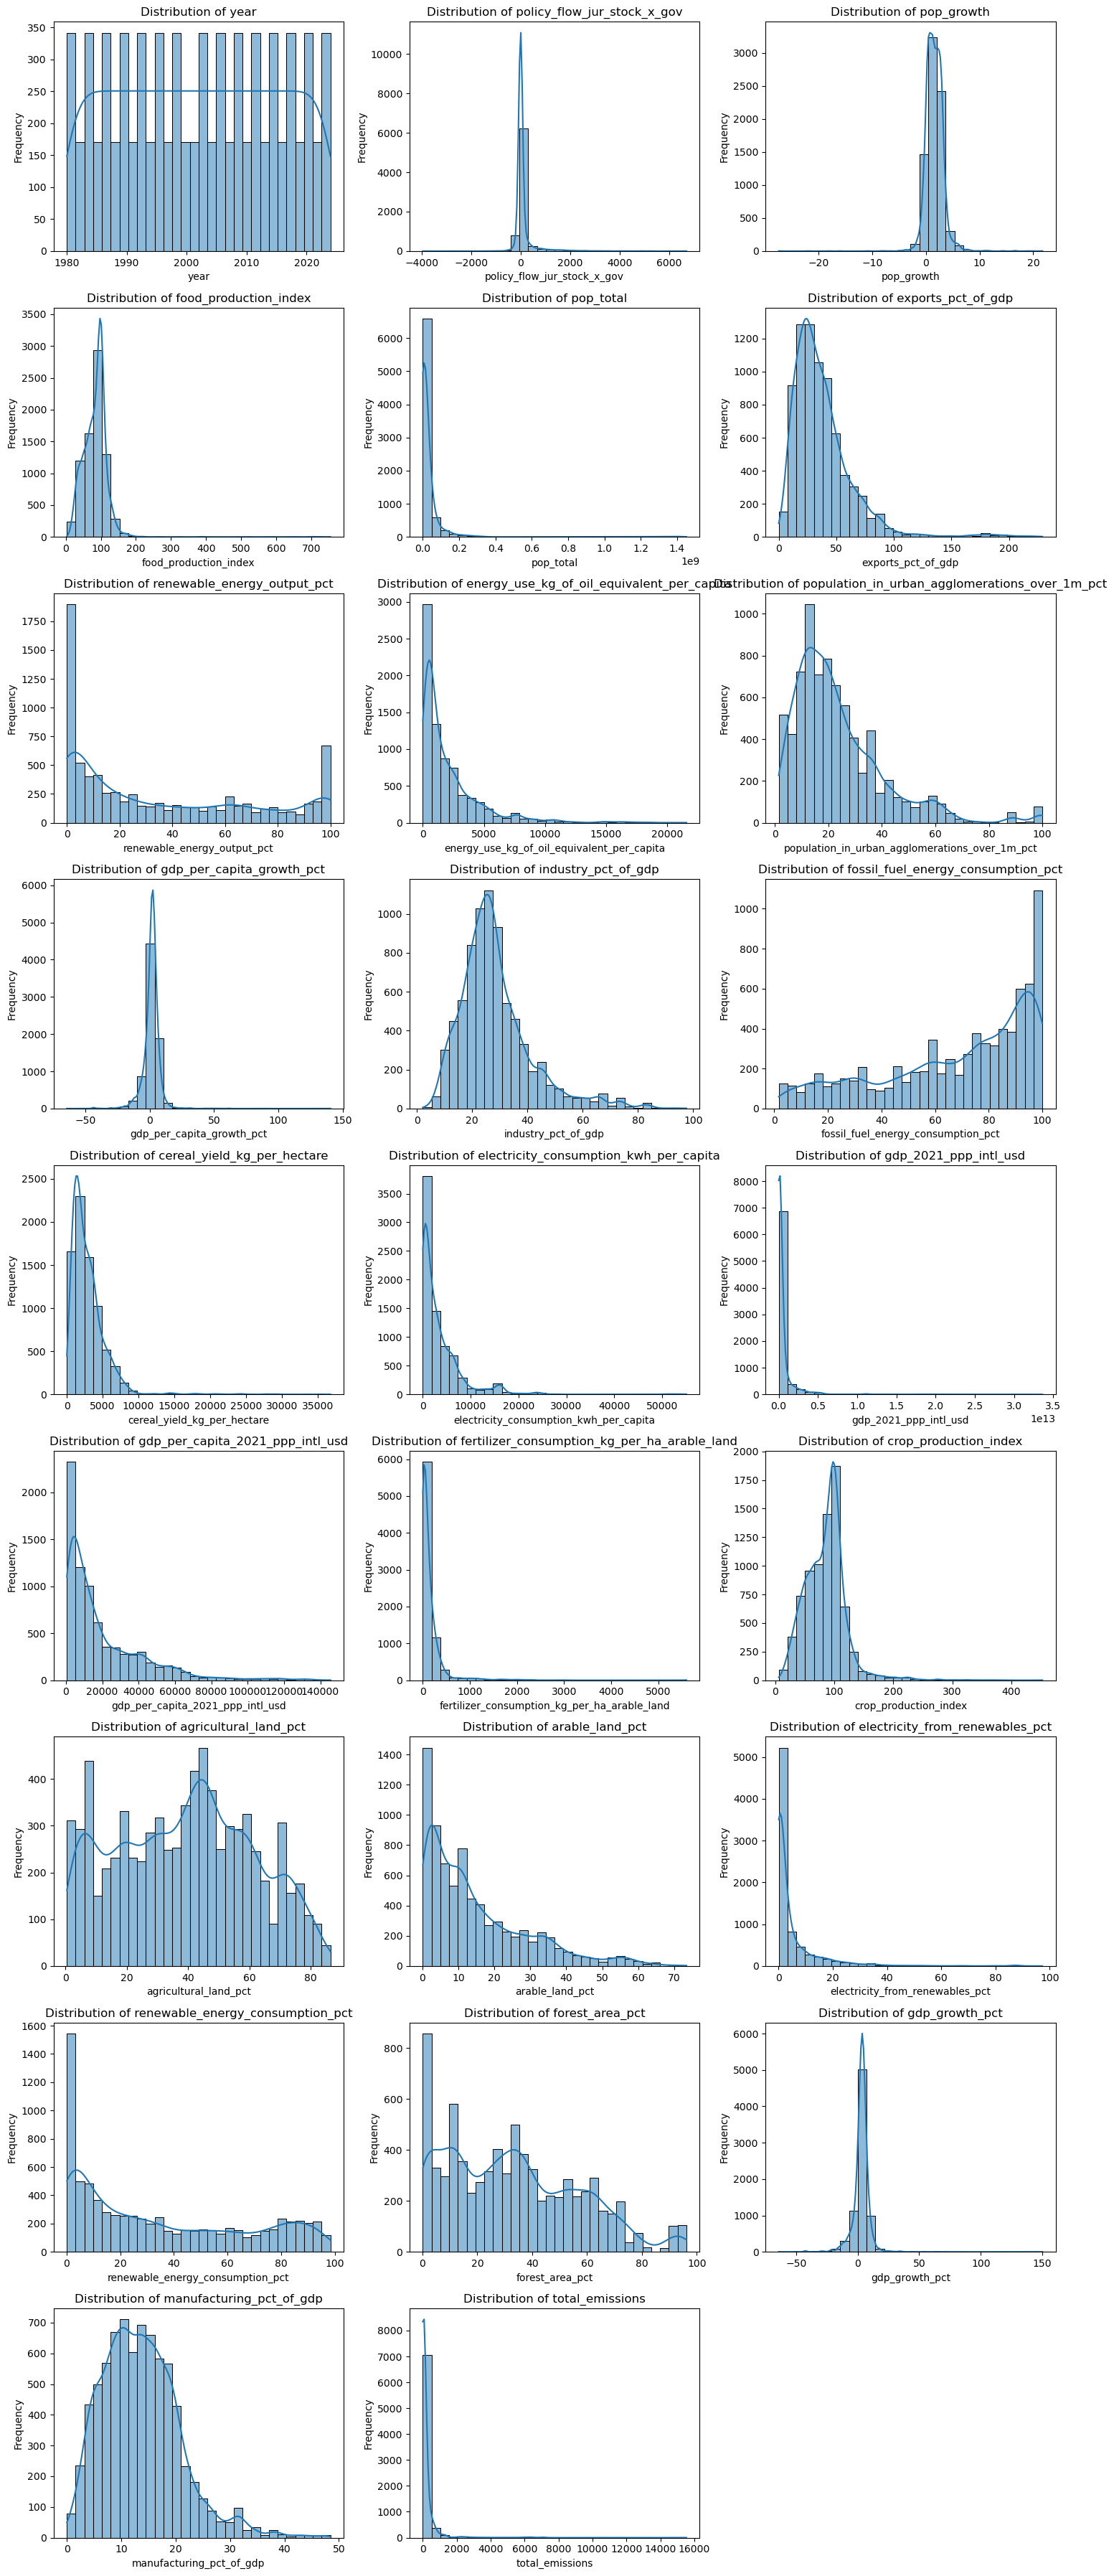

In [44]:
eda_utils.plot_numeric_fields_distributions(training_df)

In [45]:
training_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7695 entries, 90 to 7694
Data columns (total 27 columns):
 #   Column                                          Non-Null Count  Dtype  
---  ------                                          --------------  -----  
 0   iso_alpha_3                                     7695 non-null   object 
 1   year                                            7695 non-null   int64  
 2   policy_flow_jur_stock_x_gov                     7695 non-null   float64
 3   pop_growth                                      7695 non-null   float64
 4   food_production_index                           7695 non-null   float64
 5   pop_total                                       7695 non-null   float64
 6   exports_pct_of_gdp                              7695 non-null   float64
 7   renewable_energy_output_pct                     7695 non-null   float64
 8   energy_use_kg_of_oil_equivalent_per_capita      7695 non-null   float64
 9   population_in_urban_agglomerations_over_1m_pc

### Check correlation and skewness

In [46]:
target = "total_emissions"
features = [
    c for c in training_df.columns
    if c not in ["iso_alpha_3", "year", target]
]


In [47]:
def within_country_corr(df, features, target):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        if g[target].notna().sum() < 5:
            continue  # too few observations

        for f in features:
            valid = g[[f, target]].dropna()
            if len(valid) < 5:
                continue

            corr = valid[f].corr(valid[target])
            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "corr": corr
            })

    return pd.DataFrame(out)


In [48]:
corr_df = within_country_corr(
    training_df, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

In [49]:
corr_summary

,median_corr,mean_corr,abs_median_corr,n_countries
feature,,,,
pop_total,0.910242,0.638663,0.914641,171
gdp_2021_ppp_intl_usd,0.888999,0.602624,0.899306,171
food_production_index,0.848825,0.604768,0.851578,171
renewable_energy_consumption_pct,-0.774717,-0.568694,0.776900,171
crop_production_index,0.692825,0.519175,0.744464,171
policy_flow_jur_stock_x_gov,-0.394699,-0.234852,0.684679,171
renewable_energy_output_pct,-0.424117,-0.218149,0.641808,171
electricity_from_renewables_pct,0.431190,0.204347,0.621542,171
fertilizer_consumption_kg_per_ha_arable_land,0.537850,0.390977,0.587524,171


### Check Skewness

In [50]:
def within_country_skew(df, features):
    out = []

    for country, g in df.groupby("iso_alpha_3"):
        for f in features:
            x = g[f].dropna()
            if len(x) < 5:
                continue

            out.append({
                "iso_alpha_3": country,
                "feature": f,
                "skewness": skew(x)
            })

    return pd.DataFrame(out)


In [51]:
skew_df = within_country_skew(
    training_df, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)


/var/folders/tc/7lgly1g56n1cclb6ls7rcwzr0000gn/T/ipykernel_76313/2906196379.py:13: RuntimeWarning: Precision loss occurred in moment calculation due to catastrophic cancellation. This occurs when the data are nearly identical. Results may be unreliable.
  "skewness": skew(x)


In [52]:
corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
pop_total,0.910242,0.638663,0.914641,171,0.100649,0.060963,0.357604,171
gdp_2021_ppp_intl_usd,0.888999,0.602624,0.899306,171,0.531225,0.528488,NaN,169
food_production_index,0.848825,0.604768,0.851578,171,0.222643,0.222518,0.383380,171
renewable_energy_consumption_pct,-0.774717,-0.568694,0.776900,171,0.136296,0.151963,0.506075,171
crop_production_index,0.692825,0.519175,0.744464,171,0.298942,0.268515,0.402647,171
policy_flow_jur_stock_x_gov,-0.394699,-0.234852,0.684679,171,-0.819966,-0.262942,NaN,170
renewable_energy_output_pct,-0.424117,-0.218149,0.641808,171,0.431443,0.328058,0.817757,171
electricity_from_renewables_pct,0.431190,0.204347,0.621542,171,1.308741,1.372323,NaN,170
fertilizer_consumption_kg_per_ha_arable_land,0.537850,0.390977,0.587524,171,0.571132,0.646116,0.615714,171


## 5. Feature Engineering for Numeric Features

In [53]:
log_vars = [
    "pop_total",
    "gdp_2021_ppp_intl_usd",
    "gdp_per_capita_2021_ppp_intl_usd",
    "energy_use_kg_of_oil_equivalent_per_capita",
    "electricity_consumption_kwh_per_capita",
]
policy_vars = [
    "policy_flow_jur_stock_x_gov",
]
share_vars = [
    "fossil_fuel_energy_consumption_pct",
    "renewable_energy_consumption_pct",
    "electricity_from_renewables_pct",
    "population_in_urban_agglomerations_over_1m_pct",
    "industry_pct_of_gdp",
    "manufacturing_pct_of_gdp",
    "exports_pct_of_gdp",
    "renewable_energy_output_pct"
]
agri_log_vars = [
    "cereal_yield_kg_per_hectare",
    "fertilizer_consumption_kg_per_ha_arable_land",
]

agri_level_vars = [
    "food_production_index",
    "crop_production_index",
    "agricultural_land_pct",
    "arable_land_pct",
    "forest_area_pct",
]
growth_vars = [
    "gdp_growth_pct",
    "gdp_per_capita_growth_pct",
    "pop_growth",
]


In [54]:
training_df_transformed = training_df.copy()

In [55]:
# apply log transformation
for v in log_vars + agri_log_vars:
    training_df_transformed[f"log_{v}"] = np.log1p(training_df_transformed[v])


In [56]:
# Clip share 
bounded_vars = share_vars + agri_level_vars

training_df_transformed[bounded_vars] = (
    training_df_transformed[bounded_vars]
        .clip(lower=0, upper=100)
)


In [57]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'policy_flow_jur_stock_x_gov', 'pop_growth',
       'food_production_index', 'pop_total', 'exports_pct_of_gdp',
       'renewable_energy_output_pct',
       'energy_use_kg_of_oil_equivalent_per_capita',
       'population_in_urban_agglomerations_over_1m_pct',
       'gdp_per_capita_growth_pct', 'industry_pct_of_gdp',
       'fossil_fuel_energy_consumption_pct', 'cereal_yield_kg_per_hectare',
       'electricity_consumption_kwh_per_capita', 'gdp_2021_ppp_intl_usd',
       'gdp_per_capita_2021_ppp_intl_usd',
       'fertilizer_consumption_kg_per_ha_arable_land', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct',
       'electricity_from_renewables_pct', 'renewable_energy_consumption_pct',
       'forest_area_pct', 'gdp_growth_pct', 'manufacturing_pct_of_gdp',
       'total_emissions', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_energy_use_kg_of_oil_equivalent_per_capita',
 

In [58]:
final_features = (
    [f"log_{v}" for v in log_vars] +
    policy_vars +
    [f"log_{v}" for v in agri_log_vars] +
    share_vars +
    agri_level_vars +
    growth_vars
)

target = ["total_emissions"]
fixed_effect = ["iso_alpha_3"]
time_var = ["year"]

fields_to_keep = fixed_effect + time_var + final_features + target

In [59]:
# Assert physical plausibility (ignore NaNs)
for col in bounded_vars:
    assert training_df_transformed[col].dropna().min() >= 0, f"Negative values in {col}"
    assert training_df_transformed[col].dropna().max() <= 100, f"Values >100 in {col}"


In [60]:
# No infinite logs
assert np.isfinite(training_df_transformed[final_features].dropna()).all().all()


In [61]:
# Feature availability
training_df_transformed[final_features].isna().mean().sort_values(ascending=False)

log_pop_total                                       0.0
log_gdp_2021_ppp_intl_usd                           0.0
gdp_per_capita_growth_pct                           0.0
gdp_growth_pct                                      0.0
forest_area_pct                                     0.0
arable_land_pct                                     0.0
agricultural_land_pct                               0.0
crop_production_index                               0.0
food_production_index                               0.0
renewable_energy_output_pct                         0.0
exports_pct_of_gdp                                  0.0
manufacturing_pct_of_gdp                            0.0
industry_pct_of_gdp                                 0.0
population_in_urban_agglomerations_over_1m_pct      0.0
electricity_from_renewables_pct                     0.0
renewable_energy_consumption_pct                    0.0
fossil_fuel_energy_consumption_pct                  0.0
log_fertilizer_consumption_kg_per_ha_arable_land

In [62]:
training_df_transformed = training_df_transformed[fields_to_keep]

In [63]:
# create log target (idempotent)
training_df_transformed["log_total_emissions"] = np.log1p(training_df_transformed["total_emissions"])

In [64]:
print(training_df_transformed["log_total_emissions"].max())
print(training_df_transformed["log_total_emissions"].min())

9.650987386689062
0.025868037800097013


In [65]:
# drop renewable_energy_output_pct due to high missingness
training_df_transformed = training_df_transformed.drop(
    columns=["renewable_energy_output_pct"],
    errors="ignore"
)


In [66]:
training_df_transformed.columns

Index(['iso_alpha_3', 'year', 'log_pop_total', 'log_gdp_2021_ppp_intl_usd',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_energy_use_kg_of_oil_equivalent_per_capita',
       'log_electricity_consumption_kwh_per_capita',
       'policy_flow_jur_stock_x_gov', 'log_cereal_yield_kg_per_hectare',
       'log_fertilizer_consumption_kg_per_ha_arable_land',
       'fossil_fuel_energy_consumption_pct',
       'renewable_energy_consumption_pct', 'electricity_from_renewables_pct',
       'population_in_urban_agglomerations_over_1m_pct', 'industry_pct_of_gdp',
       'manufacturing_pct_of_gdp', 'exports_pct_of_gdp',
       'food_production_index', 'crop_production_index',
       'agricultural_land_pct', 'arable_land_pct', 'forest_area_pct',
       'gdp_growth_pct', 'gdp_per_capita_growth_pct', 'pop_growth',
       'total_emissions', 'log_total_emissions'],
      dtype='object')

## 6. EDA 2

In [67]:
target = "log_total_emissions"
features = [
    c for c in training_df_transformed.columns
    if c not in ["iso_alpha_3", "year", target]
]

corr_df = within_country_corr(
    training_df_transformed, features, target
)

corr_summary = (
    corr_df
    .groupby("feature")["corr"]
    .agg(
        median_corr="median",
        mean_corr="mean",
        abs_median_corr=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_corr", ascending=False)
)



skew_df = within_country_skew(
    training_df_transformed, features
)

skew_summary = (
    skew_df
    .groupby("feature")["skewness"]
    .agg(
        median_skew="median",
        mean_skew="mean",
        abs_median_skew=lambda x: np.median(np.abs(x)),
        n_countries="count"
    )
    .sort_values("abs_median_skew", ascending=False)
)

corr_summary_renamed = corr_summary.rename(
    columns={"n_countries": "n_countries_corr"}
)

skew_summary_renamed = skew_summary.rename(
    columns={"n_countries": "n_countries_skew"}
)

diagnostics = (
    corr_summary_renamed
    .join(skew_summary_renamed, how="inner")
    .sort_values(
        ["abs_median_corr", "abs_median_skew"],
        ascending=False
    )
)

diagnostics

/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3045: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/numpy/lib/_function_base_impl.py:3046: RuntimeWarning: invalid value encount

,median_corr,mean_corr,abs_median_corr,n_countries_corr,median_skew,mean_skew,abs_median_skew,n_countries_skew
feature,,,,,,,,
total_emissions,9.939650e-01,0.991034,0.993965,171,0.224064,0.228495,0.402236,171
log_pop_total,9.139802e-01,0.648104,0.919087,171,-0.172128,-0.190312,0.306844,171
food_production_index,8.053302e-01,0.609055,0.805330,171,-0.119816,-0.450641,0.396773,171
renewable_energy_consumption_pct,-7.942366e-01,-0.573035,0.803240,171,0.136296,0.151963,0.506075,171
crop_production_index,6.992640e-01,0.542339,0.699264,171,-0.256568,-0.546227,0.466562,171
policy_flow_jur_stock_x_gov,-4.069064e-01,-0.222542,0.649996,171,-0.819966,-0.262942,NaN,170
log_cereal_yield_kg_per_hectare,5.140662e-01,0.379386,0.632314,171,-0.230060,-0.250404,NaN,168
electricity_from_renewables_pct,3.864315e-01,0.178761,0.611480,171,1.308741,1.372323,NaN,170
log_fertilizer_consumption_kg_per_ha_arable_land,5.311545e-01,0.384644,0.594163,171,-0.188816,-0.191822,0.381756,171


## 7. ML

In [68]:
training_df_transformed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 7695 entries, 90 to 7694
Data columns (total 27 columns):
 #   Column                                            Non-Null Count  Dtype  
---  ------                                            --------------  -----  
 0   iso_alpha_3                                       7695 non-null   object 
 1   year                                              7695 non-null   int64  
 2   log_pop_total                                     7695 non-null   float64
 3   log_gdp_2021_ppp_intl_usd                         7695 non-null   float64
 4   log_gdp_per_capita_2021_ppp_intl_usd              7695 non-null   float64
 5   log_energy_use_kg_of_oil_equivalent_per_capita    7695 non-null   float64
 6   log_electricity_consumption_kwh_per_capita        7695 non-null   float64
 7   policy_flow_jur_stock_x_gov                       7695 non-null   float64
 8   log_cereal_yield_kg_per_hectare                   7695 non-null   float64
 9   log_fertilizer_consumpt

In [69]:
training_df_transformed.iso_alpha_3.nunique()

171

In [70]:
# Make sure the df is sorted by iso_alpha_3 and year
training_df_transformed = training_df_transformed.sort_values(by=["iso_alpha_3", "year"]).reset_index(drop=True)

In [71]:
training_df_transformed[features].isna().mean().sort_values(ascending=False).head()


log_pop_total                0.0
log_gdp_2021_ppp_intl_usd    0.0
pop_growth                   0.0
gdp_per_capita_growth_pct    0.0
gdp_growth_pct               0.0
dtype: float64

In [72]:
training_df_transformed["log_total_emissions"].describe()

count    7695.000000
mean        3.591609
std         1.825497
min         0.025868
25%         2.412047
50%         3.507230
75%         4.729390
max         9.650987
Name: log_total_emissions, dtype: float64

In [73]:
training_df["year"].min(), training_df["year"].max()

(np.int64(1980), np.int64(2024))

In [74]:
features.remove("total_emissions")

In [75]:
xgb_params = dict(
    n_estimators=300,      # Enough trees, not excessive for this size
    max_depth=6,           # Controls overfitting, 4–6 is common
    learning_rate=0.07,    # Slower learning, safer default than 0.1
    subsample=0.8,         # Row sampling for robustness
    colsample_bytree=0.8,  # Feature sampling per tree for robustness
    reg_alpha=0.2,         # L1 regularization, good for tabular data
    reg_lambda=1.0,        # L2 regularization (default 1.0, safe)
    random_state=42,       # For reproducibility
    n_jobs=-1,             # Use all cores
    verbosity=0
)

print("Running regression without group feature...")

ra = RegressionAnalysis(
    df=training_df_transformed.drop(columns=["total_emissions"]),
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    scaler_type="minmax",
    feature_cols=features,
    include_year=False
)

ra.cross_validate()
ra.fit()
ra.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/preprocessing/_encoders.py:246: UserWarning: Found unknown categories in columns [0] during transform. These unknown categories will be encoded as all zeros
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/py

ElasticNet            0.3904          nan
RandomForest          0.4966       0.4223
XGBoost               0.4350       0.3746
Median                1.4420       1.4774

Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.1838         0.2072            0.2259            0.2532               38.29               57.19
RandomForest            0.0182         0.1960            0.0306            0.3073                2.91               51.23
XGBoost                 0.0319         0.1541            0.0433            0.2139                5.75               61.34
Median                  1.4484         1.4374            1.8286            1.8514

{'ElasticNet': {'train_mae_log': 0.1838433268790532,
  'test_mae_log': 0.20717393664178918,
  'train_rmse_log': 0.22590144552645827,
  'test_rmse_log': 0.25315296150459893,
  'train_mae_level': np.float64(38.29300518818615),
  'test_mae_level': np.float64(57.18540726579858)},
 'RandomForest': {'train_mae_log': 0.01816926513730915,
  'test_mae_log': 0.19599399392392228,
  'train_rmse_log': 0.03063526015005987,
  'test_rmse_log': 0.30731783484791464,
  'train_mae_level': np.float64(2.9101476129800465),
  'test_mae_level': np.float64(51.22568660117605)},
 'XGBoost': {'train_mae_log': 0.03185203324861464,
  'test_mae_log': 0.15405314440622242,
  'train_rmse_log': 0.04332809550783957,
  'test_rmse_log': 0.2139167196447112,
  'train_mae_level': np.float64(5.754737480388333),
  'test_mae_level': np.float64(61.3427408411787)},
 'Median': {'train_mae_log': 1.4483734860756257,
  'test_mae_log': 1.4373677164022514,
  'train_rmse_log': 1.8286449559555706,
  'test_rmse_log': 1.851409513059391,
  't

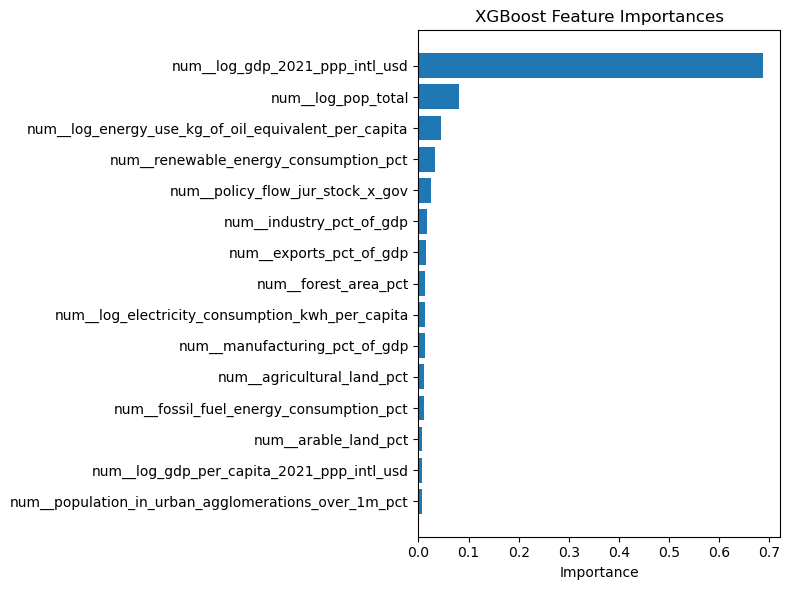

In [76]:
ra.plot_feature_importances(model="XGboost", top_n=15)

In [77]:
# Table
country_errors = ra.per_country_errors(model="randomForest")
country_errors.sort_values(by="mae_level", ascending=False)


,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
169,IDN,6,1.066267,1.106746,2369.743215
80,CHN,6,0.126818,0.134567,1774.450186
43,USA,6,0.064986,0.071054,398.550957
158,FRA,6,0.459932,0.486625,245.364735
119,IRN,6,0.231422,0.240125,203.010113
...,...,...,...,...,...
5,BLZ,6,0.018461,0.022877,0.036460
9,VCT,6,0.022929,0.026299,0.027421
6,GRD,6,0.020545,0.021432,0.024956
2,DMA,6,0.009877,0.010343,0.011295


In [78]:
# # Plot
# ra.plot_per_country_errors(model="XGBoost", metric="mae_log", top_k=25)
# ra.plot_per_country_errors(model="XGBoost", metric="mae_level", top_k=25)


In [79]:
# Table
policy_country = ra.policy_effect_by_country(model="XGBoost")
policy_country

,iso_alpha_3,mean_delta_log,mean_delta_level,median_delta_level,n_obs
0,PRI,-0.549208,-11.704803,-11.736382,6
1,MLT,-0.370417,-2.073842,-2.211188,6
2,LTU,-0.358116,-11.046295,-10.939193,6
3,SVN,-0.263295,-7.102779,-5.938684,6
4,PAN,-0.243599,-5.747234,-6.158587,6
...,...,...,...,...,...
166,NER,0.358102,14.042638,13.311083,6
167,MLI,0.365287,15.090984,15.414663,6
168,ETH,0.368821,44.784092,46.767708,6
169,TCD,0.429092,24.593874,22.149498,6


In [80]:
# # Table
# policy_country = ra.policy_effect_by_country(model="XGBoost")
# policy_country.head()

# # Plot
# ra.plot_policy_effects(model="XGBoost", top_k=25)


## Test each feature to select the only the best

In [81]:
fpe = FeaturePredictiveEvaluator(
    df=training_df_transformed,
    target_col="log_total_emissions",
    country_col="iso_alpha_3",
    year_col="year",
    group_col="iso_alpha_3",
    include_year=False,
    log_target=False,
    scaler_type="minmax"
)

In [82]:
features

['log_pop_total',
 'log_gdp_2021_ppp_intl_usd',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_electricity_consumption_kwh_per_capita',
 'policy_flow_jur_stock_x_gov',
 'log_cereal_yield_kg_per_hectare',
 'log_fertilizer_consumption_kg_per_ha_arable_land',
 'fossil_fuel_energy_consumption_pct',
 'renewable_energy_consumption_pct',
 'electricity_from_renewables_pct',
 'population_in_urban_agglomerations_over_1m_pct',
 'industry_pct_of_gdp',
 'manufacturing_pct_of_gdp',
 'exports_pct_of_gdp',
 'food_production_index',
 'crop_production_index',
 'agricultural_land_pct',
 'arable_land_pct',
 'forest_area_pct',
 'gdp_growth_pct',
 'gdp_per_capita_growth_pct',
 'pop_growth']

Sure — here are concise bullets for what each metric means and how to interpret it.

---

### **`median_within_group_std`**

* **What it measures:** Typical (median) **within-country variability** of the feature over time.
* **Interpretation:**

  * **Near 0** → feature barely changes within each country → likely **not useful** for prediction (hard to learn effect).
  * **Higher value** → feature varies within countries → more chance it adds predictive signal beyond country fixed effects.
* **Rule of thumb:** If your model already has iso fixed effects, you want features with **meaningful within-country variation**.

---

### **`rmse_base_ridge`**

* **What it measures:** Cross-validated RMSE of the **baseline Ridge model** (usually using only iso fixed effects ± year).
* **Interpretation:**

  * This is your **reference performance**.
  * Lower is better.
* **Use:** Compare against `rmse_with_feature_ridge` to see if the candidate feature helps.

---

### **`rmse_with_feature_ridge`**

* **What it measures:** Cross-validated RMSE of the Ridge model after adding the **candidate feature** to the baseline.
* **Interpretation:**

  * Lower than baseline → feature improves prediction.
  * Higher than baseline → feature adds noise / is not predictive / harms generalization.
* **Use:** Absolute performance with the feature included.

---

### **`rmse_delta_ridge`**

* **Definition:**
  [
  \text{rmse_with_feature_ridge} - \text{rmse_base_ridge}
  ]
* **What it measures:** The **marginal predictive contribution** of the feature (under Ridge).
* **Interpretation:**

  * **Negative** → good ✅ (RMSE decreased → feature helps)
  * **Near 0** → neutral (feature doesn’t matter)
  * **Positive** → bad ❌ (feature worsens prediction)
* **This is the key “keep/drop” metric.**

---

### **`permutation_importance`**

* **What it measures:** How much performance degrades when you **shuffle the feature**, breaking its relationship with the target (on the fitted model).
* **Interpretation:**

  * **Positive and large** → model relies on the feature → predictive.
  * **Near 0** → model doesn’t use it much.
  * **Negative** (can happen due to noise) → feature may be useless or even harmful.
* **Use:** Good as a **robust check** even when RMSE changes are small.

---

If you want, I can also give you simple thresholds (like “keep if rmse_delta < -0.01”) depending on your target scaling (log emissions vs level emissions).


In [83]:
# collect series into a dict then make a DataFrame (features as rows)
out = {}
for v in features:
    s = fpe.evaluate_feature(v, test_xgboost=False)
    s.name = v
    out[v] = s

In [84]:
feat_evaluation_results_df = pd.DataFrame(out).T  # each row = feature, columns = series index
feat_evaluation_results_df.head()

,median_within_group_std,mae_base_ridge,mae_with_feature_ridge,mae_delta_ridge,mae_base_ridge_level,mae_with_feature_ridge_level,mae_delta_ridge_level,permutation_importance,mae_base_xgb,mae_with_feature_xgb,mae_delta_xgb,mae_base_xgb_level,mae_with_feature_xgb_level,mae_delta_xgb_level
log_pop_total,0.203478,1.59471,0.920089,-0.674621,1.59471,0.920089,-0.674621,2.023992,NaN,NaN,NaN,NaN,NaN,NaN
log_gdp_2021_ppp_intl_usd,0.385179,1.59471,0.732789,-0.861921,1.59471,0.732789,-0.861921,0.812079,NaN,NaN,NaN,NaN,NaN,NaN
log_gdp_per_capita_2021_ppp_intl_usd,0.219934,1.59471,1.555018,-0.039692,1.59471,1.555018,-0.039692,0.302722,NaN,NaN,NaN,NaN,NaN,NaN
log_energy_use_kg_of_oil_equivalent_per_capita,0.139043,1.59471,1.601411,0.006702,1.59471,1.601411,0.006702,0.240070,NaN,NaN,NaN,NaN,NaN,NaN
log_electricity_consumption_kwh_per_capita,0.225845,1.59471,1.893124,0.298414,1.59471,1.893124,0.298414,0.277169,NaN,NaN,NaN,NaN,NaN,NaN


In [85]:
feat_evaluation_results_df[["mae_delta_ridge_level", "permutation_importance"]].sort_values(by="mae_delta_ridge_level", ascending=True)

,mae_delta_ridge_level,permutation_importance
log_gdp_2021_ppp_intl_usd,-0.861921,0.812079
log_pop_total,-0.674621,2.023992
industry_pct_of_gdp,-0.064106,0.008677
log_gdp_per_capita_2021_ppp_intl_usd,-0.039692,0.302722
exports_pct_of_gdp,-0.008695,0.009109
electricity_from_renewables_pct,-0.001806,0.000632
manufacturing_pct_of_gdp,-0.000533,0.000080
gdp_per_capita_growth_pct,-0.000479,0.000002
gdp_growth_pct,0.000263,0.000019
fossil_fuel_energy_consumption_pct,0.004116,0.000252


### Retraining with less features

In [86]:
top_preds = [
    # "log_gdp_2021_ppp_intl_usd",
    # "log_pop_total",
    "log_gdp_per_capita_2021_ppp_intl_usd",
    "log_energy_use_kg_of_oil_equivalent_per_capita",
]

In [87]:
retraining_top_fields = fixed_effect + time_var + top_preds  + [target, "total_emissions"]
retraining_top_fields


['iso_alpha_3',
 'year',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'log_total_emissions',
 'total_emissions']

In [88]:
retraining_df_top_preds = training_df_transformed[retraining_top_fields].copy()
# retraining_df_top_preds = retraining_df_top_preds.drop(columns=["log_policy_flow_raw_stock"])
# remove log_policy_flow_raw_stock from top_preds
# top_preds.remove("log_policy_flow_raw_stock")

retraining_df_top_preds

,iso_alpha_3,year,log_gdp_per_capita_2021_ppp_intl_usd,log_energy_use_kg_of_oil_equivalent_per_capita,log_total_emissions,total_emissions
0,AGO,1980,9.032376,6.228706,3.307180,26.308007
1,AGO,1981,9.032376,6.228706,3.254307,24.901662
2,AGO,1982,9.032376,6.228706,3.342043,27.276840
3,AGO,1983,9.032376,6.228706,3.396239,28.851607
4,AGO,1984,9.032376,6.228706,3.410605,29.283552
...,...,...,...,...,...,...
7690,ZWE,2020,8.418195,5.925745,3.250134,24.793786
7691,ZWE,2021,8.482206,6.007630,3.337537,27.149709
7692,ZWE,2022,8.524717,6.034493,3.368179,28.025627
7693,ZWE,2023,8.560065,6.034493,3.438011,30.124985


In [89]:
xgb_params = dict(
    n_estimators=1200,
    max_depth=3,
    learning_rate=0.03,
    subsample=0.7,
    colsample_bytree=0.7,
    min_child_weight=10,
    gamma=0.2,
    reg_lambda=5.0,
    reg_alpha=0.5,
    random_state=42,
    n_jobs=-1,
    verbosity=0,
)


enet_params = dict(
    l1_ratio=[0.05, 0.1, 0.3, 0.5, 0.7, 0.9, 0.95],
    n_alphas=200,          # wider alpha search
    eps=1e-3,              # allow smaller alphas
    cv=7,
    max_iter=30000,
    n_jobs=-1,
    random_state=42,
)

rf_params = dict(
    n_estimators=800,
    max_depth=14,          # cap depth to reduce overfit
    min_samples_leaf=5,    # stronger regularization
    min_samples_split=10,
    max_features=0.6,      # less correlated trees
    bootstrap=True,
    random_state=42,
    n_jobs=-1,
)


print("Running regression without group feature...")

ra_top_preds = RegressionAnalysis(
    df=retraining_df_top_preds.drop(columns=["total_emissions"]),
    target_col="log_total_emissions",
    group_col="iso_alpha_3",
    year_col="year",
    holdout_years=6,
    xgb_params=xgb_params,
    rf_params=rf_params,
    enet_params=enet_params,
    scaler_type="minmax",
    feature_cols=top_preds,
)

ra_top_preds.cross_validate()
ra_top_preds.fit()
ra_top_preds.evaluate()

Running regression without group feature...

Cross-validation results:
------------------------------------------------------------------------------------------
Model               Time MAE    Group MAE


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(
/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_desc

ElasticNet            1.2801          nan
RandomForest          1.3694       1.3432
XGBoost               1.4401       1.4399
Median                1.4420       1.4774


/opt/miniconda3/envs/etpe_env/lib/python3.12/site-packages/sklearn/linear_model/_coordinate_descent.py:1622: FutureWarning: 'n_alphas' was deprecated in 1.7 and will be removed in 1.9. 'alphas' now accepts an integer value which removes the need to pass 'n_alphas'. The default value of 'alphas' will change from None to 100 in 1.9. Pass an explicit value to 'alphas' and leave 'n_alphas' to its default value to silence this warning.
  warnings.warn(



Holdout evaluation:
------------------------------------------------------------------------------------------------------------------------
Model          Train MAE (log) Test MAE (log)  Train RMSE (log)   Test RMSE (log)   Train MAE (level)    Test MAE (level)
------------------------------------------------------------------------------------------------------------------------
ElasticNet              0.2220         0.3609            0.2832            0.4345               55.50               98.77
RandomForest            0.5925         1.0880            0.8715            1.4675              130.18              261.51
XGBoost                 1.0388         1.2375            1.3502            1.5745              177.54              269.20
Median                  1.4484         1.4374            1.8286            1.8514              199.84              275.01


{'ElasticNet': {'train_mae_log': 0.22199386424351744,
  'test_mae_log': 0.3609292094677362,
  'train_rmse_log': 0.2832490931951846,
  'test_rmse_log': 0.43446038722688285,
  'train_mae_level': np.float64(55.49739145598352),
  'test_mae_level': np.float64(98.76821346001842)},
 'RandomForest': {'train_mae_log': 0.5924608266598004,
  'test_mae_log': 1.0880168151887843,
  'train_rmse_log': 0.8714607993911005,
  'test_rmse_log': 1.467525979735521,
  'train_mae_level': np.float64(130.18113247080478),
  'test_mae_level': np.float64(261.50734289110864)},
 'XGBoost': {'train_mae_log': 1.0388252261860522,
  'test_mae_log': 1.237451862203641,
  'train_rmse_log': 1.350216055743416,
  'test_rmse_log': 1.5744596435164053,
  'train_mae_level': np.float64(177.5423722639403),
  'test_mae_level': np.float64(269.19704718805554)},
 'Median': {'train_mae_log': 1.4483734860756257,
  'test_mae_log': 1.4373677164022514,
  'train_rmse_log': 1.8286449559555706,
  'test_rmse_log': 1.851409513059391,
  'train_mae

In [90]:
# Table
country_erros_best_preds = ra_top_preds.per_country_errors(model="ElasticNet")
country_erros_best_preds.sort_values(by="mae_level", ascending=False).head(50)

,iso_alpha_3,n_obs,mae_log,rmse_log,mae_level
78,CHN,6,0.225195,0.225866,2980.821280
65,IND,6,0.199264,0.199579,706.246769
55,RUS,6,0.178873,0.179063,404.066952
147,IRN,6,0.495940,0.496305,382.162416
110,BRA,6,0.317472,0.317902,342.617554
95,IDN,6,0.287891,0.293371,290.341484
11,USA,6,0.046037,0.051722,280.683850
120,SAU,6,0.376195,0.376286,245.631224
140,FRA,6,0.466888,0.470296,243.921755
118,GBR,6,0.374565,0.380070,191.498661


In [91]:
def plot_country_mae_histograms(
    df,
    mae_level_col="mae_level",
    mae_log_col="mae_log",
    bins_level=30,
    bins_log=30,
    figsize=(12, 5),
    save_path=None
):
    """
    Side-by-side histograms of per-country MAE:
    - Left: MAE in emissions levels (MtCO2e)
    - Right: MAE in log space

    Parameters
    ----------
    df : pd.DataFrame
        Per-country error DataFrame.
    mae_level_col : str
        Column with MAE in level space (MtCO2e).
    mae_log_col : str
        Column with MAE in log space.
    bins_level : int
        Number of bins for level MAE histogram.
    bins_log : int
        Number of bins for log MAE histogram.
    figsize : tuple
        Figure size.
    save_path : str, optional
        Path to save the figure (PDF recommended).
    """

    vals_level = df[mae_level_col].dropna().values
    vals_log = df[mae_log_col].dropna().values

    fig, axes = plt.subplots(1, 2, figsize=figsize)

    # ---- Level-space histogram ----
    axes[0].hist(
        vals_level,
        bins=bins_level,
        edgecolor="black",
        alpha=0.8
    )
    median_level = np.median(vals_level)
    axes[0].axvline(
        median_level,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {median_level:.2f}"
    )
    axes[0].set_xlabel("MAE (MtCO$_2$e)")
    axes[0].set_ylabel("Number of countries")
    axes[0].set_title("MAE distribution (emissions level)")
    axes[0].legend()

    # ---- Log-space histogram ----
    axes[1].hist(
        vals_log,
        bins=bins_log,
        edgecolor="black",
        alpha=0.8
    )
    median_log = np.median(vals_log)
    axes[1].axvline(
        median_log,
        color="black",
        linestyle="--",
        linewidth=1.5,
        label=f"Median = {median_log:.3f}"
    )
    axes[1].set_xlabel("MAE (log emissions)")
    axes[1].set_title("MAE distribution (log space)")
    axes[1].legend()

    fig.tight_layout()

    if save_path is not None:
        fig.savefig(save_path, bbox_inches="tight")

    plt.show()
    plt.close(fig)


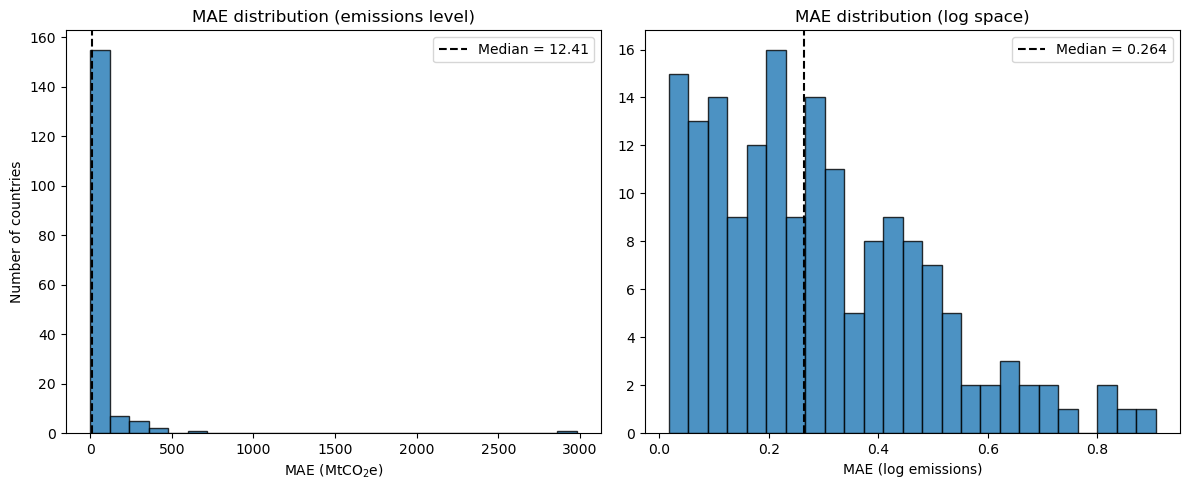

In [92]:
plot_country_mae_histograms(
    df=country_erros_best_preds,
    bins_level=25,
    bins_log=25,
    save_path="img/country_mae_histograms.pdf"
)


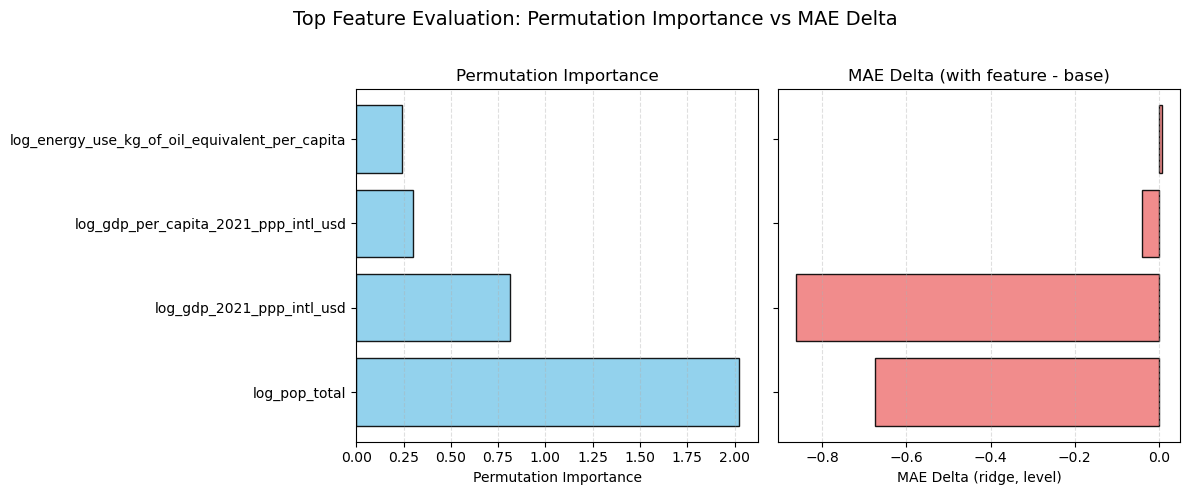

In [93]:
# Filter the feature evaluation results to only include top features
top_feats_evaluation_df = feat_evaluation_results_df[feat_evaluation_results_df.index.isin(top_preds)]
top_feats_evaluation_df

# Combined visualization of permutation importance and MAE delta for top features
order = top_feats_evaluation_df.sort_values("permutation_importance", ascending=True).index

fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True)

# Left: Permutation importance
axes[0].barh(
    y=order,
    width=top_feats_evaluation_df.loc[order, "permutation_importance"],
    color="skyblue",
    edgecolor="k",
    alpha=0.9
)
axes[0].set_xlabel("Permutation Importance")
axes[0].set_title("Permutation Importance")
axes[0].grid(axis="x", linestyle="--", alpha=0.4)

# Right: MAE delta (level)
axes[1].barh(
    y=order,
    width=top_feats_evaluation_df.loc[order, "mae_delta_ridge_level"],
    color="lightcoral",
    edgecolor="k",
    alpha=0.9
)
axes[1].set_xlabel("MAE Delta (ridge, level)")
axes[1].set_title("MAE Delta (with feature - base)")
axes[1].grid(axis="x", linestyle="--", alpha=0.4)

# Invert y to have most important feature on top
axes[0].invert_yaxis()

fig.suptitle("Top Feature Evaluation: Permutation Importance vs MAE Delta", fontsize=14)
fig.tight_layout(rect=[0, 0, 1, 0.96])
fig.savefig("img/top_features_evaluation_combined.pdf", bbox_inches="tight")
plt.show()
plt.close(fig)

In [107]:
# # Table
# policy_country_15_feat = ra_15_feat.policy_effect_by_country(model="XGBoost")
# policy_country_15_feat

In [110]:
# ra_15_feat.plot_feature_importances(model="XGBoost", top_n=15)

In [111]:
# feat_importances = ra_15_feat.top_n_features(model="XGBoost", n=15, return_importance=True)
# feat_importances

In [112]:

# # ---- Clean feature names ----
# features = [f.replace("num__", "") for f, _ in feat_importances]
# importances = np.array([float(v) for _, v in feat_importances])

# # ---- Sort (ascending for horizontal bar plot) ----
# order = np.argsort(importances)
# features = np.array(features)[order]
# importances = importances[order]

# # ---- Plot ----
# plt.figure(figsize=(8, 0.4 * len(features)))
# plt.barh(features, importances)
# plt.xlabel("Feature importance")
# plt.title("XGBoost feature importance (top 15 drivers)")
# plt.tight_layout()

# # ---- Save for LaTeX ----
# plt.savefig("xgb_feature_importance_top15.pdf")
# plt.savefig("xgb_feature_importance_top15.png", dpi=300)

# plt.show()

## 8. Save selected model

We will keep the one trained with the top 15 features as it reduced the errors and performed better in the per-country error analysis.

In [113]:
retraining_df_top_preds.columns

Index(['iso_alpha_3', 'year', 'log_gdp_2021_ppp_intl_usd', 'log_pop_total',
       'log_gdp_per_capita_2021_ppp_intl_usd',
       'log_energy_use_kg_of_oil_equivalent_per_capita', 'industry_pct_of_gdp',
       'renewable_energy_consumption_pct', 'forest_area_pct',
       'policy_flow_jur_stock_x_gov', 'log_total_emissions',
       'total_emissions'],
      dtype='object')

In [114]:
top_preds

['log_gdp_2021_ppp_intl_usd',
 'log_pop_total',
 'log_gdp_per_capita_2021_ppp_intl_usd',
 'log_energy_use_kg_of_oil_equivalent_per_capita',
 'industry_pct_of_gdp',
 'renewable_energy_consumption_pct',
 'forest_area_pct',
 'policy_flow_jur_stock_x_gov']

In [163]:
# --------------------------------------------------
# Save the training data with predictions
# --------------------------------------------------
retraining_df_top_preds.to_csv(
    os.path.join(TRAINING_DIR_PATH, "training_df_top_preds_with_raw_emissions.csv"),
    index=False
)

retraining_df_top_preds.to_csv(
    os.path.join(TRAINING_DIR_PATH, "training_df_top_preds.csv"),
    index=False
)

# --------------------------------------------------
# Select trained pipelines to save
# --------------------------------------------------
trained_pipelines = {
    "enet_top_preds": ra_top_preds.pipe_enet,   # <- THIS is the key line
}

rewrite_existing_models = False

# --------------------------------------------------
# Save pipelines
# --------------------------------------------------
for name, pipeline in trained_pipelines.items():
    model_file_name = f"{name}_pipeline.pkl"
    model_path = os.path.join(MODELS_DIR_PATH, model_file_name)

    if os.path.exists(model_path) and not rewrite_existing_models:
        print(f"Model {model_file_name} already exists. Skipping save.")
        continue

    if os.path.exists(model_path):
        print(f"Overwriting existing model at {model_path}")
    else:
        print(f"Saving model to {model_path}")

    joblib.dump(pipeline, model_path)

Saving model to /Users/tony/Documents/research_project/etpe_project/ml_scripts/output/models/enet_top_preds_pipeline.pkl
